In [1]:
from google.colab import files
uploaded = files.upload()

Saving RAVDESS_Emotional_speech_audio.zip to RAVDESS_Emotional_speech_audio.zip


In [3]:
import zipfile

zip_ref = zipfile.ZipFile("RAVDESS_Emotional_speech_audio.zip", 'r')
zip_ref.extractall("dataset")
zip_ref.close()

In [4]:
!pip install librosa

In [5]:
import librosa
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [6]:
def get_emotion(filename):
    emotion_code = filename.split("-")[2]

    emotions = {
        "01":"neutral",
        "02":"calm",
        "03":"happy",
        "04":"sad",
        "05":"angry",
        "06":"fear",
        "07":"disgust",
        "08":"surprise"
    }

    return emotions[emotion_code]

In [7]:
def extract_features(file):

    audio, sr = librosa.load(file, duration=3, offset=0.5)

    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)

    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr).T, axis=0)

    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sr).T, axis=0)

    return np.hstack([mfcc, chroma, mel])

In [8]:
X = []
y = []

dataset_path = "dataset"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = get_emotion(file)

            features = extract_features(file_path)

            X.append(features)
            y.append(emotion)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [11]:
pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9270833333333334


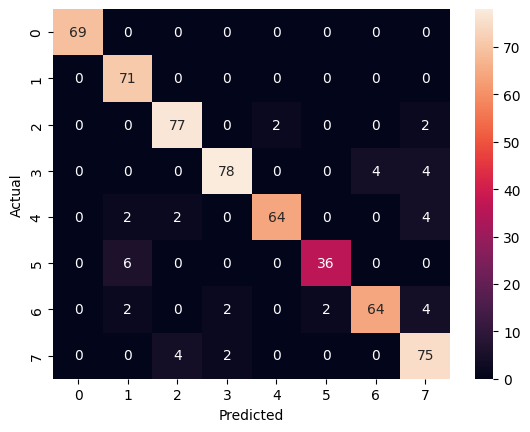

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
import pickle

pickle.dump(model, open("emotion_model.pkl", "wb"))

In [14]:
for i in range(10):
    print("Actual:", y_test[i], "| Predicted:", pred[i])

Actual: calm | Predicted: calm
Actual: happy | Predicted: happy
Actual: happy | Predicted: happy
Actual: calm | Predicted: calm
Actual: disgust | Predicted: happy
Actual: angry | Predicted: angry
Actual: fear | Predicted: fear
Actual: angry | Predicted: angry
Actual: happy | Predicted: happy
Actual: surprise | Predicted: surprise


In [15]:
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9270833333333334


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        69
        calm       0.88      1.00      0.93        71
     disgust       0.93      0.95      0.94        81
        fear       0.95      0.91      0.93        86
       happy       0.97      0.89      0.93        72
     neutral       0.95      0.86      0.90        42
         sad       0.94      0.86      0.90        74
    surprise       0.84      0.93      0.88        81

    accuracy                           0.93       576
   macro avg       0.93      0.92      0.93       576
weighted avg       0.93      0.93      0.93       576



In [17]:
from google.colab import files
files.download("emotion_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>